# Reproducing the PCA-Based Covariance-Forecasting Analysis

This notebook is an executable companion to the bachelor thesis
*PCA-based Forecasting of Portfolio Volatility*. It reproduces the
full empirical workflow from the supplied market-data archives to the
reported forecast comparison.

The analysis addresses the following research question:

> How well does a PCA-based covariance forecasting approach that reduces
> the problem to forecasting the dominant indicator with an
> ARFIMA(0, d, 0) model perform in one-step-ahead out-of-sample
> covariance-matrix forecasting relative to naive benchmarks?

## In brief

The notebook first verifies the identity and structure of all supplied
data files. It then constructs the covariance matrices, applies the
chronological training/holdout split, estimates the fixed PCA
representation, produces the three forecast variants, evaluates their
errors, and recreates the four figures used in the thesis. The final
checks compare the newly computed results with the reference tables
stored in the repository and run all unit tests.

The notebook does not reimplement the mathematical methods. Each step
calls the corresponding function in the analysis package. The notebook
and command-line workflow therefore use the same tested implementation.

## Study Design and Reading Guide

The case study uses one-minute closing prices for BTCUSDT, ETHUSDT, and
BNBUSDT from January through December 2024. Consecutive log returns are
grouped into complete, non-overlapping blocks of 30 observations. One
centred 3 × 3 sample covariance matrix is estimated for each block.

The first 8,783 covariance matrices form the training period. The
remaining 8,784 matrices form the chronological holdout used for forecast
evaluation. A single PCA basis is estimated from the training matrices
and then kept fixed. Within that common coordinate system, the first
diagonal element is called the **dominant indicator**. It measures
variation along the leading training-based PCA direction.

Three one-step-ahead forecasts are compared:

1. **Direct naive covariance:** the most recently observed covariance
   matrix is carried forward.
2. **Naive dominant indicator:** the most recently observed dominant
   indicator is carried forward and mapped back to a covariance matrix.
3. **ARFIMA dominant indicator:** the dominant indicator is forecast with
   ARFIMA(0, d, 0) and mapped back through the same fixed PCA basis.

The notebook follows four stages: data preparation, representation,
forecasting, and evaluation. Short notes after the main outputs explain
what each table establishes and what it does not establish.

### Assumptions and Scope Boundaries

- The exact 36 Binance ZIP archives and 36 official checksum sidecars are
  supplied under `data/raw/binance/`.
- All timestamps are interpreted in UTC.
- The tracked configuration in
  `config/experiments/2024_full_year.yaml` defines the experiment.
- The data originate from the official Binance Public Data archive at
  <https://data.binance.vision/>.
- The findings are descriptive for the selected assets, period, split,
  and error measures. They do not establish causal mechanisms or general
  superiority for other portfolios, markets, or periods.

### 1. Prepare the Reproducible Environment

The first cell locates the project directory and records the software
versions used for this run. No packages are installed from inside the
notebook. The complete dependency resolution is defined by `uv.lock`.

Automatic project detection allows the notebook to be opened either from
the repository root or from the `notebooks/` directory.

In [ ]:
from contextlib import redirect_stdout
from pathlib import Path
import io
import os
import platform
import subprocess
import sys
import tempfile

import matplotlib
import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (
            (candidate / "pyproject.toml").is_file()
            and (candidate / "src" / "pca_covariance_forecasting").is_dir()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Open the notebook from "
        "inside the extracted analysis repository."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "config" / "experiments" / "2024_full_year.yaml"
DATA_DIRECTORY = PROJECT_ROOT / "data" / "raw" / "binance"
TRAINING_OBSERVATION_COUNT = 8_783


def resolve_source_revision() -> str:
    snapshot_revision = PROJECT_ROOT / "SOURCE_COMMIT.txt"
    if snapshot_revision.is_file():
        return snapshot_revision.read_text(encoding="utf-8").strip()
    return (
        "Development checkout; the exact submission commit is recorded "
        "in the package README."
    )


environment_summary = pd.Series(
    {
        "Source revision": resolve_source_revision(),
        "Python": platform.python_version(),
        "NumPy": np.__version__,
        "pandas": pd.__version__,
        "Matplotlib": matplotlib.__version__,
        "PyYAML": yaml.__version__,
        "Project directory": PROJECT_ROOT.name,
    },
    name="value",
).to_frame()
display(environment_summary)

,value
Source revision,Development checkout; the exact submission com...
Python,3.12.13
NumPy,2.5.1
pandas,3.0.5
Matplotlib,3.11.1
PyYAML,6.0.3
Project directory,bachelor-thesis-pca-covariance-forecasting


### 2. Load the Analysis Functions

The core computations are imported directly from the data, covariance,
PCA, forecasting, and evaluation modules. The archive validator and the
plotting functions used for the thesis figures are imported from their
modules as well. This keeps every mathematical operation on the same
tested code path used by the command-line workflow.

In [ ]:
from pca_covariance_forecasting.covariance import compute_block_covariances
from pca_covariance_forecasting.data import (
    compute_log_returns,
    load_closing_prices,
)
from pca_covariance_forecasting.evaluation import (
    compute_aggregated_relative_frobenius_error,
    compute_covariance_rmse,
    compute_covariance_squared_frobenius_losses,
    compute_psd_diagnostics,
    compute_relative_frobenius_errors,
)
from pca_covariance_forecasting.experiment_config import load_experiment_config
from pca_covariance_forecasting.forecasting import (
    construct_direct_naive_covariance_forecasts,
    construct_dominant_indicator_covariance_forecasts,
    fit_and_forecast_arfima_0d0_holdout,
)
from pca_covariance_forecasting.pca import (
    compute_approximation_errors,
    compute_reference_covariance,
    compute_reference_eigendecomposition,
    construct_reference_basis_approximations,
    transform_covariances_from_reference_basis,
    transform_covariances_to_reference_basis,
)
from scripts import validate_binance_spot_klines as binance_validation
from scripts.generate_thesis_figures import (
    configure_plot_style,
    plot_approximation_error_distributions,
    plot_covariance_rmse_reduction,
    plot_cumulative_loss_difference,
    plot_reference_pca_variance_share,
)

DIRECT_NAIVE = "direct_naive_covariance"
NAIVE_INDICATOR = "naive_dominant_indicator"
ARFIMA_INDICATOR = "arfima_dominant_indicator"
METHOD_LABELS = {
    DIRECT_NAIVE: "Direct naive covariance",
    NAIVE_INDICATOR: "Naive dominant indicator",
    ARFIMA_INDICATOR: "ARFIMA dominant indicator",
}

## Data Preparation

The input files are checked before any model is estimated. This section
documents the experiment settings, validates every archive, and traces
how the raw price observations become covariance matrices.

### 3. Read the Tracked Experiment Configuration

Symbols, months, sampling interval, and covariance-block length are read
from the tracked YAML file. Keeping these choices outside the notebook
prevents hidden or manually edited parameters from affecting the run.

In [ ]:
config = load_experiment_config(CONFIG_PATH)
expected_archive_count = len(config.symbols) * len(config.months)

configuration_summary = pd.Series(
    {
        "Symbols": ", ".join(config.symbols),
        "Interval": config.interval,
        "First month": config.months[0],
        "Last month": config.months[-1],
        "Monthly archives": expected_archive_count,
        "Returns per covariance block": config.block_size,
        "Training matrices": TRAINING_OBSERVATION_COUNT,
    },
    name="value",
).to_frame()
display(configuration_summary)

,value
Symbols,"BTCUSDT, ETHUSDT, BNBUSDT"
Interval,1m
First month,2024-01
Last month,2024-12
Monthly archives,36
Returns per covariance block,30
Training matrices,8783


### 4. Verify the Supplied Data Files

Each monthly archive must pass six checks: the official SHA-256 checksum,
the expected ZIP contents, the 12-field candlestick (Kline) schema, complete monthly
UTC coverage, continuous one-minute timestamps, and finite positive open, high, low, and close (OHLC)
prices. A failure in any file stops the notebook immediately.

The checks establish file identity and structural suitability for this
analysis. They do not independently verify the economic correctness of
prices reported by the exchange.

In [ ]:
archive_paths = sorted(DATA_DIRECTORY.glob("*.zip"))
checksum_paths = sorted(DATA_DIRECTORY.glob("*.zip.CHECKSUM"))
if len(archive_paths) != expected_archive_count:
    raise FileNotFoundError(
        f"Expected {expected_archive_count} ZIP archives under "
        f"{DATA_DIRECTORY}, found {len(archive_paths)}."
    )
if len(checksum_paths) != expected_archive_count:
    raise FileNotFoundError(
        f"Expected {expected_archive_count} checksum sidecars under "
        f"{DATA_DIRECTORY}, found {len(checksum_paths)}."
    )

validation_log = io.StringIO()
with redirect_stdout(validation_log):
    for symbol in config.symbols:
        for month in config.months:
            binance_validation.validate_archive(symbol, month, config)

validation_summary = pd.DataFrame(
    {
        "Check": [
            "Official SHA-256 checksum",
            "Expected ZIP contents",
            "12-field Kline schema",
            "Complete monthly UTC coverage",
            "Continuous one-minute timestamps",
            "Finite positive OHLC prices",
        ],
        "Result": [f"{expected_archive_count}/{expected_archive_count}"] * 6,
    }
)
display(validation_summary)

,Check,Result
0,Official SHA-256 checksum,36/36
1,Expected ZIP contents,36/36
2,12-field Kline schema,36/36
3,Complete monthly UTC coverage,36/36
4,Continuous one-minute timestamps,36/36
5,Finite positive OHLC prices,36/36


### 5. Transform Prices into Covariance Matrices

First, consecutive log returns are computed from the one-minute closing
prices. The returns are then divided into complete blocks of 30. For each
block, a centred sample covariance matrix is calculated with divisor
`b - 1 = 29`. Any trailing returns that cannot form a complete block are
excluded.

The following count table provides an audit trail from price observations
to the final number of covariance matrices.

In [ ]:
closing_prices = load_closing_prices(DATA_DIRECTORY, config)
log_returns = compute_log_returns(closing_prices)
covariance_matrices = compute_block_covariances(
    log_returns,
    block_size=config.block_size,
)
covariance_timestamps = (
    covariance_matrices.index.get_level_values("timestamp").unique()
)

excluded_trailing_returns = len(log_returns) % config.block_size
data_counts = pd.Series(
    {
        "Price observations per asset": len(closing_prices),
        "Log returns per asset": len(log_returns),
        "Returns in complete blocks": (
            len(covariance_timestamps) * config.block_size
        ),
        "Excluded trailing returns": excluded_trailing_returns,
        "Covariance matrices": len(covariance_timestamps),
        "Missing closing prices": int(closing_prices.isna().sum().sum()),
        "Missing log returns": int(log_returns.isna().sum().sum()),
    },
    name="count",
).to_frame()

assert closing_prices.index.tz is not None
assert data_counts.loc["Missing closing prices", "count"] == 0
assert data_counts.loc["Missing log returns", "count"] == 0
display(data_counts)

,count
Price observations per asset,527040
Log returns per asset,527039
Returns in complete blocks,527010
Excluded trailing returns,29
Covariance matrices,17567
Missing closing prices,0
Missing log returns,0


**How to read the counts.** Computing consecutive returns removes the
first price observation, leaving 527,039 returns per asset. Of these,
527,010 form 17,567 complete 30-return blocks. The remaining 29 returns
are excluded because they cannot form another complete covariance block.
No interpolation or imputation is used.

### 6. Separate Training and Holdout Periods

The covariance matrices remain in chronological order and are never
shuffled. The first 8,783 matrices are used to estimate the PCA basis and
ARFIMA parameters. The later 8,784 matrices are reserved for forecast
evaluation.

During the holdout, an observation becomes part of the known history only
after its one-step-ahead forecast has been made. The fitted model
parameters remain fixed throughout the holdout.

In [ ]:
if len(covariance_timestamps) <= TRAINING_OBSERVATION_COUNT:
    raise ValueError("The configured period is too short for the fixed split.")

training_timestamps = covariance_timestamps[:TRAINING_OBSERVATION_COUNT]
holdout_timestamps = covariance_timestamps[TRAINING_OBSERVATION_COUNT:]
matrix_timestamps = covariance_matrices.index.get_level_values("timestamp")

training_covariances = covariance_matrices.loc[
    matrix_timestamps.isin(training_timestamps)
].copy()
holdout_covariances = covariance_matrices.loc[
    matrix_timestamps.isin(holdout_timestamps)
].copy()

assert training_covariances.index.get_level_values("timestamp").unique().equals(
    training_timestamps
)
assert holdout_covariances.index.get_level_values("timestamp").unique().equals(
    holdout_timestamps
)

split_summary = pd.DataFrame(
    {
        "Matrices": [len(training_timestamps), len(holdout_timestamps)],
        "First timestamp (UTC)": [training_timestamps[0], holdout_timestamps[0]],
        "Last timestamp (UTC)": [training_timestamps[-1], holdout_timestamps[-1]],
    },
    index=["Training", "Holdout"],
)
display(split_summary)

,Matrices,First timestamp (UTC),Last timestamp (UTC)
Training,8783,2024-01-01 00:30:00+00:00,2024-07-01 23:30:00+00:00
Holdout,8784,2024-07-02 00:00:00+00:00,2024-12-31 23:30:00+00:00


**Why the boundary matters.** The table identifies the exact final
training timestamp and first holdout timestamp. PCA and ARFIMA parameters
are estimated only from rows above this boundary, which prevents holdout
information from entering model fitting.

## Representation, Forecasts, and Evaluation

With the inputs validated and the split fixed, the following sections
reproduce the PCA representation, the indicator forecasts, the covariance
reconstructions, and the reported holdout comparison.

### 7. Estimate the Fixed PCA Reference Basis

The reference covariance is the element-wise average of all training
covariance matrices. Its eigenvectors define one common coordinate system
for both training and holdout matrices. The eigenvalues are ordered from
largest to smallest.

The reported variance share refers to the eigenvalue sum of this averaged
training-reference covariance. It should not be interpreted as the share
of all temporal covariance dynamics explained by the first component.

In [ ]:
reference_covariance = compute_reference_covariance(training_covariances)
reference_basis, reference_eigenvalues = (
    compute_reference_eigendecomposition(reference_covariance)
)
variance_shares = reference_eigenvalues.divide(reference_eigenvalues.sum())
reference_pca_summary = reference_eigenvalues.to_frame(name="eigenvalue")
reference_pca_summary["variance_share_percent"] = variance_shares * 100.0

assert np.isclose(variance_shares.sum(), 1.0)
pca_display = reference_pca_summary.rename(
    columns={
        "eigenvalue": "Reference eigenvalue",
        "variance_share_percent": "Variance share (%)",
    },
    index={
        "component_1": "PC1",
        "component_2": "PC2",
        "component_3": "PC3",
    },
)
display(pca_display.style.format({
    "Reference eigenvalue": "{:.12e}",
    "Variance share (%)": "{:.2f}",
}))

,Reference eigenvalue,Variance share (%)
PC1,1.703311343866e-06,79.73
PC2,3.123891115229e-07,14.62
PC3,1.206120931557e-07,5.65


**Interpretation.** PC1 represents 79.73% of the eigenvalue sum of the
averaged training-reference covariance. This concentration motivates the
one-indicator experiment, but it does not by itself show that one
indicator is sufficient. That question is examined by the approximation
errors in the next section.

### 8. Evaluate the One-Indicator Representation

Every observed covariance matrix is transformed into the fixed PCA basis.
Its first diagonal element is retained as the time-varying dominant
indicator. The other two diagonal elements are fixed at their
training-reference eigenvalues, and transformed off-diagonal elements are
set to zero before the matrix is reconstructed in asset coordinates.

This step uses the observed dominant indicator, not a forecast. It
therefore measures **representation error**, which is distinct from the
forecast error evaluated later. The aggregated relative Frobenius error
sums squared matrix norms before taking the ratio; it is not the arithmetic
mean of the interval-level relative errors.

In [ ]:
transformed_covariances = transform_covariances_to_reference_basis(
    covariances=covariance_matrices,
    reference_basis=reference_basis,
)
approximation_in_reference_basis = construct_reference_basis_approximations(
    transformed_covariances=transformed_covariances,
    reference_eigenvalues=reference_eigenvalues,
)
covariance_approximations = transform_covariances_from_reference_basis(
    transformed_covariances=approximation_in_reference_basis,
    reference_basis=reference_basis,
)
approximation_errors = compute_approximation_errors(
    covariances=covariance_matrices,
    approximated_covariances=covariance_approximations,
)

approximation_timestamps = approximation_errors.index.get_level_values("timestamp")
training_approximation_errors = approximation_errors.loc[
    approximation_timestamps.isin(training_timestamps)
].copy()
holdout_approximation_errors = approximation_errors.loc[
    approximation_timestamps.isin(holdout_timestamps)
].copy()

training_relative_errors = compute_relative_frobenius_errors(
    errors=training_approximation_errors,
    covariance_matrices=training_covariances,
)
holdout_relative_errors = compute_relative_frobenius_errors(
    errors=holdout_approximation_errors,
    covariance_matrices=holdout_covariances,
)
aggregated_training_error = compute_aggregated_relative_frobenius_error(
    errors=training_approximation_errors,
    covariance_matrices=training_covariances,
)
aggregated_holdout_error = compute_aggregated_relative_frobenius_error(
    errors=holdout_approximation_errors,
    covariance_matrices=holdout_covariances,
)

approximation_summary = pd.DataFrame(
    {
        "Training": {
            "aggregated_error": aggregated_training_error,
            "mean_interval_error": training_relative_errors.mean(),
            "median_interval_error": training_relative_errors.median(),
            "95th_percentile_interval_error": training_relative_errors.quantile(0.95),
            "maximum_interval_error": training_relative_errors.max(),
        },
        "Holdout": {
            "aggregated_error": aggregated_holdout_error,
            "mean_interval_error": holdout_relative_errors.mean(),
            "median_interval_error": holdout_relative_errors.median(),
            "95th_percentile_interval_error": holdout_relative_errors.quantile(0.95),
            "maximum_interval_error": holdout_relative_errors.max(),
        },
    }
)
approximation_summary.index.name = "error_summary"
approximation_display = approximation_summary.multiply(100.0).rename(
    index={
        "aggregated_error": "Aggregated relative error (%)",
        "mean_interval_error": "Mean interval-level error (%)",
        "median_interval_error": "Median interval-level error (%)",
        "95th_percentile_interval_error": "95th percentile (%)",
        "maximum_interval_error": "Maximum interval-level error (%)",
    }
)
display(approximation_display.style.format("{:.2f}"))

,Training,Holdout
error_summary,,
Aggregated relative error (%),35.19,46.38
Mean interval-level error (%),53.77,49.89
Median interval-level error (%),39.64,36.49
95th percentile (%),146.78,133.39
Maximum interval-level error (%),909.17,1007.08


**Interpretation.** The aggregated error rises from about 35.2% in
training to 46.4% in the holdout. This result shows that a high leading
reference share and a low reconstruction error are different concepts.
The interval-level medians and aggregated values need not move together.
The aggregated measure gives greater influence to covariance matrices
with larger Frobenius norms, whereas the median gives every interval the
same rank-based weight.

### 9. Fit ARFIMA and Forecast the Dominant Indicator

ARFIMA(0, d, 0) is fitted once to the training portion of the dominant
indicator. The fitted mean and fractional parameter remain fixed. For
every holdout timestamp, the next indicator value is forecast from the
observations available at that point, so the known history grows without
introducing look-ahead information.

The innovation variance is reported as part of the fitted model but is not
used in the implemented point forecast. A boundary-warning value of `False` means
that the selected value of `d` is not at the practical search limits.

In [ ]:
first_component = reference_basis.columns[0]
dominant_indicator = (
    transformed_covariances
    .xs(first_component, level="component")
    .loc[:, first_component]
    .copy()
)
dominant_indicator.name = "dominant_indicator"

naive_indicator_forecasts = (
    dominant_indicator.shift(1)
    .iloc[TRAINING_OBSERVATION_COUNT:]
    .copy()
)
naive_indicator_forecasts.name = "naive_dominant_indicator_forecast"
arfima_indicator_forecasts, fitted_arfima = (
    fit_and_forecast_arfima_0d0_holdout(
        series=dominant_indicator,
        training_observation_count=TRAINING_OBSERVATION_COUNT,
    )
)

assert naive_indicator_forecasts.index.equals(holdout_timestamps)
assert arfima_indicator_forecasts.index.equals(holdout_timestamps)
assert not naive_indicator_forecasts.isna().any()
assert not arfima_indicator_forecasts.isna().any()

arfima_summary = pd.Series(
    {
        "Training mean": f"{float(fitted_arfima['mean']):.12e}",
        "Fractional parameter d": f"{float(fitted_arfima['d']):.12f}",
        "Innovation variance": (
            f"{float(fitted_arfima['innovation_variance']):.12e}"
        ),
        "Boundary warning": str(bool(fitted_arfima["boundary_warning"])),
        "Holdout forecasts": f"{len(arfima_indicator_forecasts):,}",
    },
    name="value",
).to_frame()
display(arfima_summary)

,value
Training mean,1.703311343866e-06
Fractional parameter d,0.260204057880
Innovation variance,2.429232902833e-11
Boundary warning,False
Holdout forecasts,"8,784"


**Interpretation.** The fitted value `d = 0.260204` is positive and lies
inside the practical search interval. It describes the dependence
selected for this training series; by itself, it is not evidence of a
universal long-memory property. The boundary-warning value of `False` confirms that
the optimum was not selected at either search limit.

### 10. Construct the Three Covariance Forecasts

The naive and ARFIMA indicator forecasts are each inserted as the first
diagonal element of the fixed PCA representation. The remaining
components stay at their training-reference values, after which the
matrices are transformed back to asset coordinates.

The direct naive benchmark follows a different route: it uses the entire
covariance matrix observed at the preceding timestamp. All three methods
must produce one matrix for every holdout timestamp with identical index
alignment.

In [ ]:
direct_naive_forecasts = construct_direct_naive_covariance_forecasts(
    covariance_matrices=covariance_matrices,
    training_observation_count=TRAINING_OBSERVATION_COUNT,
)
naive_indicator_covariance_forecasts = (
    construct_dominant_indicator_covariance_forecasts(
        dominant_indicator_forecasts=naive_indicator_forecasts,
        reference_basis=reference_basis,
        reference_eigenvalues=reference_eigenvalues,
    )
)
arfima_indicator_covariance_forecasts = (
    construct_dominant_indicator_covariance_forecasts(
        dominant_indicator_forecasts=arfima_indicator_forecasts,
        reference_basis=reference_basis,
        reference_eigenvalues=reference_eigenvalues,
    )
)

forecasts_by_method = {
    DIRECT_NAIVE: direct_naive_forecasts,
    NAIVE_INDICATOR: naive_indicator_covariance_forecasts,
    ARFIMA_INDICATOR: arfima_indicator_covariance_forecasts,
}
for method, forecasts in forecasts_by_method.items():
    assert forecasts.index.equals(holdout_covariances.index), method
    assert not forecasts.isna().any().any(), method

pd.Series(
    {METHOD_LABELS[method]: len(forecasts.index.unique("timestamp"))
     for method, forecasts in forecasts_by_method.items()},
    name="holdout_forecasts",
).to_frame()

,holdout_forecasts
Direct naive covariance,8784
Naive dominant indicator,8784
ARFIMA dominant indicator,8784


### 11. Compare Forecast Accuracy and Matrix Validity

Root mean squared error (RMSE) is reported for all matrix entries, for the
three diagonal variance entries, and for the six off-diagonal covariance
entries. Smaller values indicate lower forecast error. The displayed RMSE
values are scaled by 10⁶ for readability.

Positive-semidefiniteness is checked separately because a covariance
forecast must retain this matrix property. Squared Frobenius losses are
also computed by timestamp for the descriptive cumulative-loss figure.

In [ ]:
rmse_by_method = pd.DataFrame(
    {
        method: compute_covariance_rmse(holdout_covariances - forecasts)
        for method, forecasts in forecasts_by_method.items()
    }
).T
rmse_by_method.index = [METHOD_LABELS[method] for method in rmse_by_method.index]
rmse_by_method.index.name = "method"

psd_summary = pd.DataFrame(
    {
        method: compute_psd_diagnostics(forecasts)
        for method, forecasts in forecasts_by_method.items()
    }
).T
psd_summary.index = [METHOD_LABELS[method] for method in psd_summary.index]
psd_summary.index.name = "method"
psd_summary[["raw_negative_count", "non_psd_count"]] = (
    psd_summary[["raw_negative_count", "non_psd_count"]].astype(int)
)

direct_naive_losses = compute_covariance_squared_frobenius_losses(
    holdout_covariances - direct_naive_forecasts
)["overall"]
arfima_losses = compute_covariance_squared_frobenius_losses(
    holdout_covariances - arfima_indicator_covariance_forecasts
)["overall"]

rmse_display = rmse_by_method.multiply(1e6).rename(
    columns={
        "overall": "Overall RMSE (× 10⁻⁶)",
        "diagonal": "Diagonal RMSE (× 10⁻⁶)",
        "off-diagonal": "Off-diagonal RMSE (× 10⁻⁶)",
    }
)
psd_display = psd_summary.rename(columns={
    "minimum_eigenvalue": "Minimum eigenvalue",
    "raw_negative_count": "Raw negative count",
    "non_psd_count": "Non-PSD count",
    "non_psd_share": "Non-PSD share",
})
display(rmse_display.style.format("{:.4f}"))
display(psd_display.style.format({
    "Minimum eigenvalue": "{:.12e}",
    "Non-PSD share": "{:.2%}",
}))

,Overall RMSE (× 10⁻⁶),Diagonal RMSE (× 10⁻⁶),Off-diagonal RMSE (× 10⁻⁶)
method,,,
Direct naive covariance,3.5946,4.8148,2.7912
Naive dominant indicator,3.3764,4.1127,2.9399
ARFIMA dominant indicator,2.7788,3.6676,2.2038


,Minimum eigenvalue,Raw negative count,Non-PSD count,Non-PSD share
method,,,,
Direct naive covariance,1.839651951968e-09,0,0,0.00%
Naive dominant indicator,2.592184703644e-08,0,0,0.00%
ARFIMA dominant indicator,1.206120931557e-07,0,0,0.00%


**How to read the tables.** The RMSE table is scaled by 10⁶ only for
display; the underlying calculations remain in the original covariance
units. Lower RMSE is better. The PSD table shows zero non-PSD matrices for
every method, so the evaluated forecasts retain the required covariance-
matrix property.

### 12. Recreate the Four Thesis Figures

The four figures answer complementary questions:

1. How concentrated is the training-reference eigenvalue sum?
2. How is the one-indicator approximation error distributed?
3. How do the indicator methods change RMSE relative to direct
   covariance persistence?
4. When during the holdout does the aggregate ARFIMA advantage arise?

The same plotting functions used to generate the thesis figures are applied
to the objects computed above. The files are created in a temporary
directory and embedded in the executed notebook, so rerunning it does not
modify the tracked figure files.

#### `02_reference_pca_variance_share`

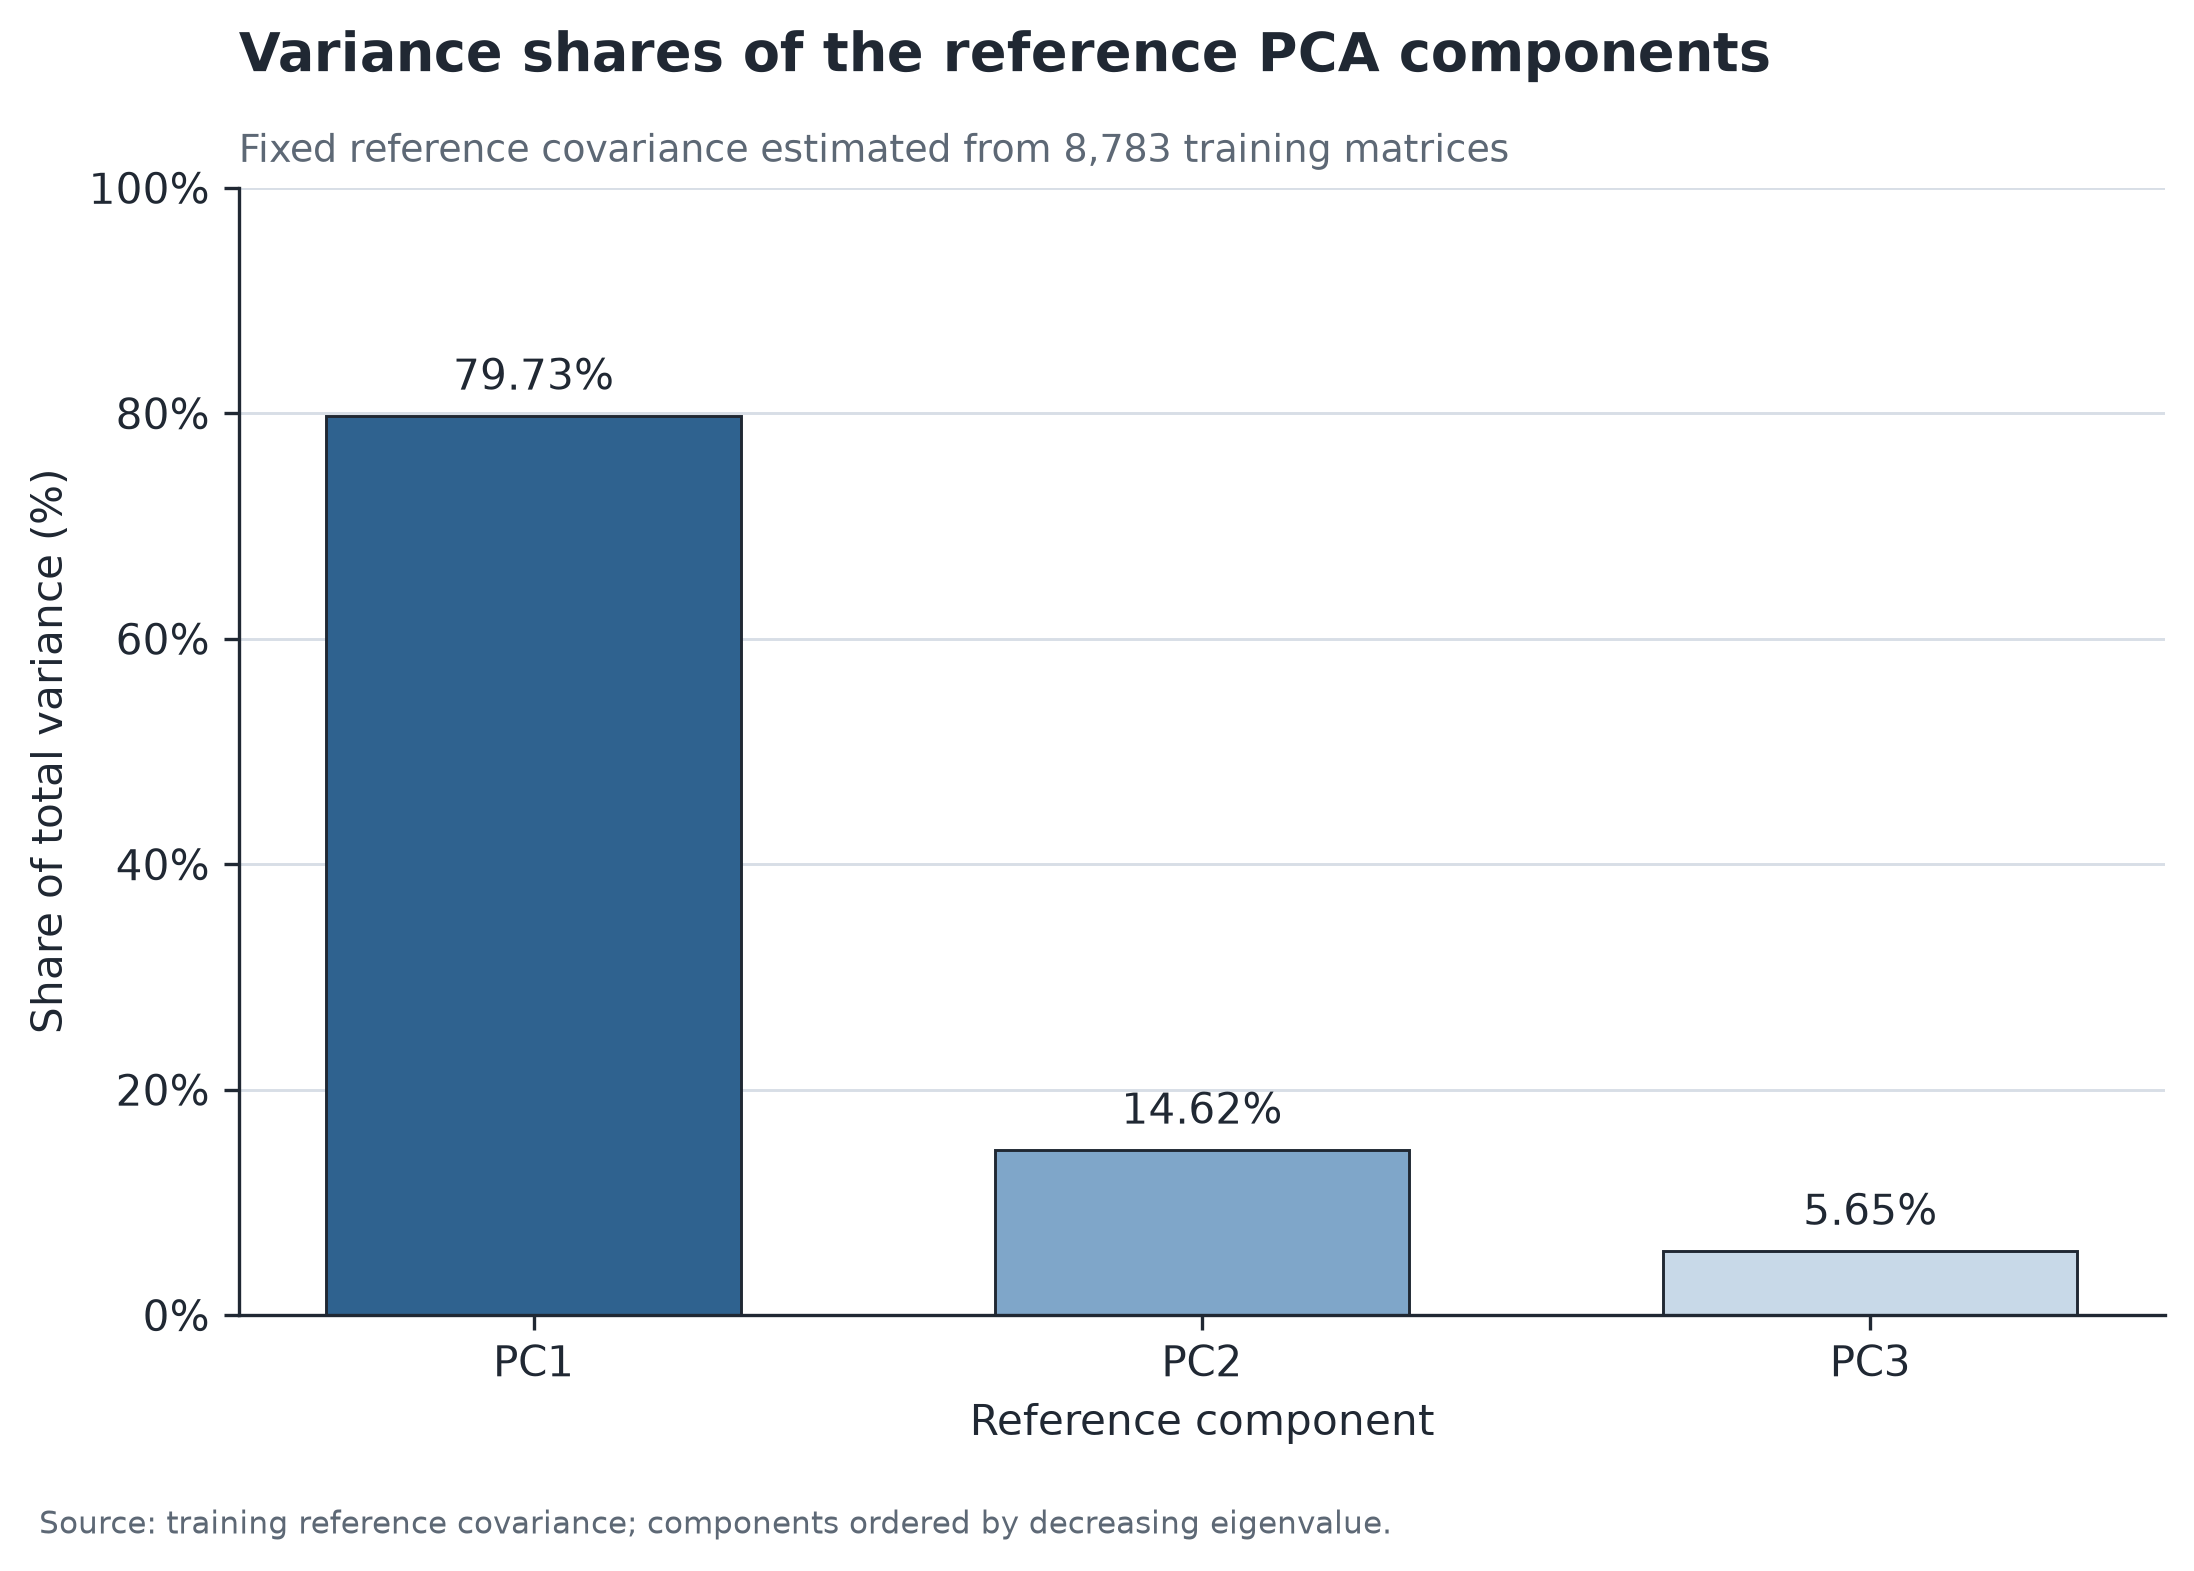

#### `04_approximation_error_distributions`

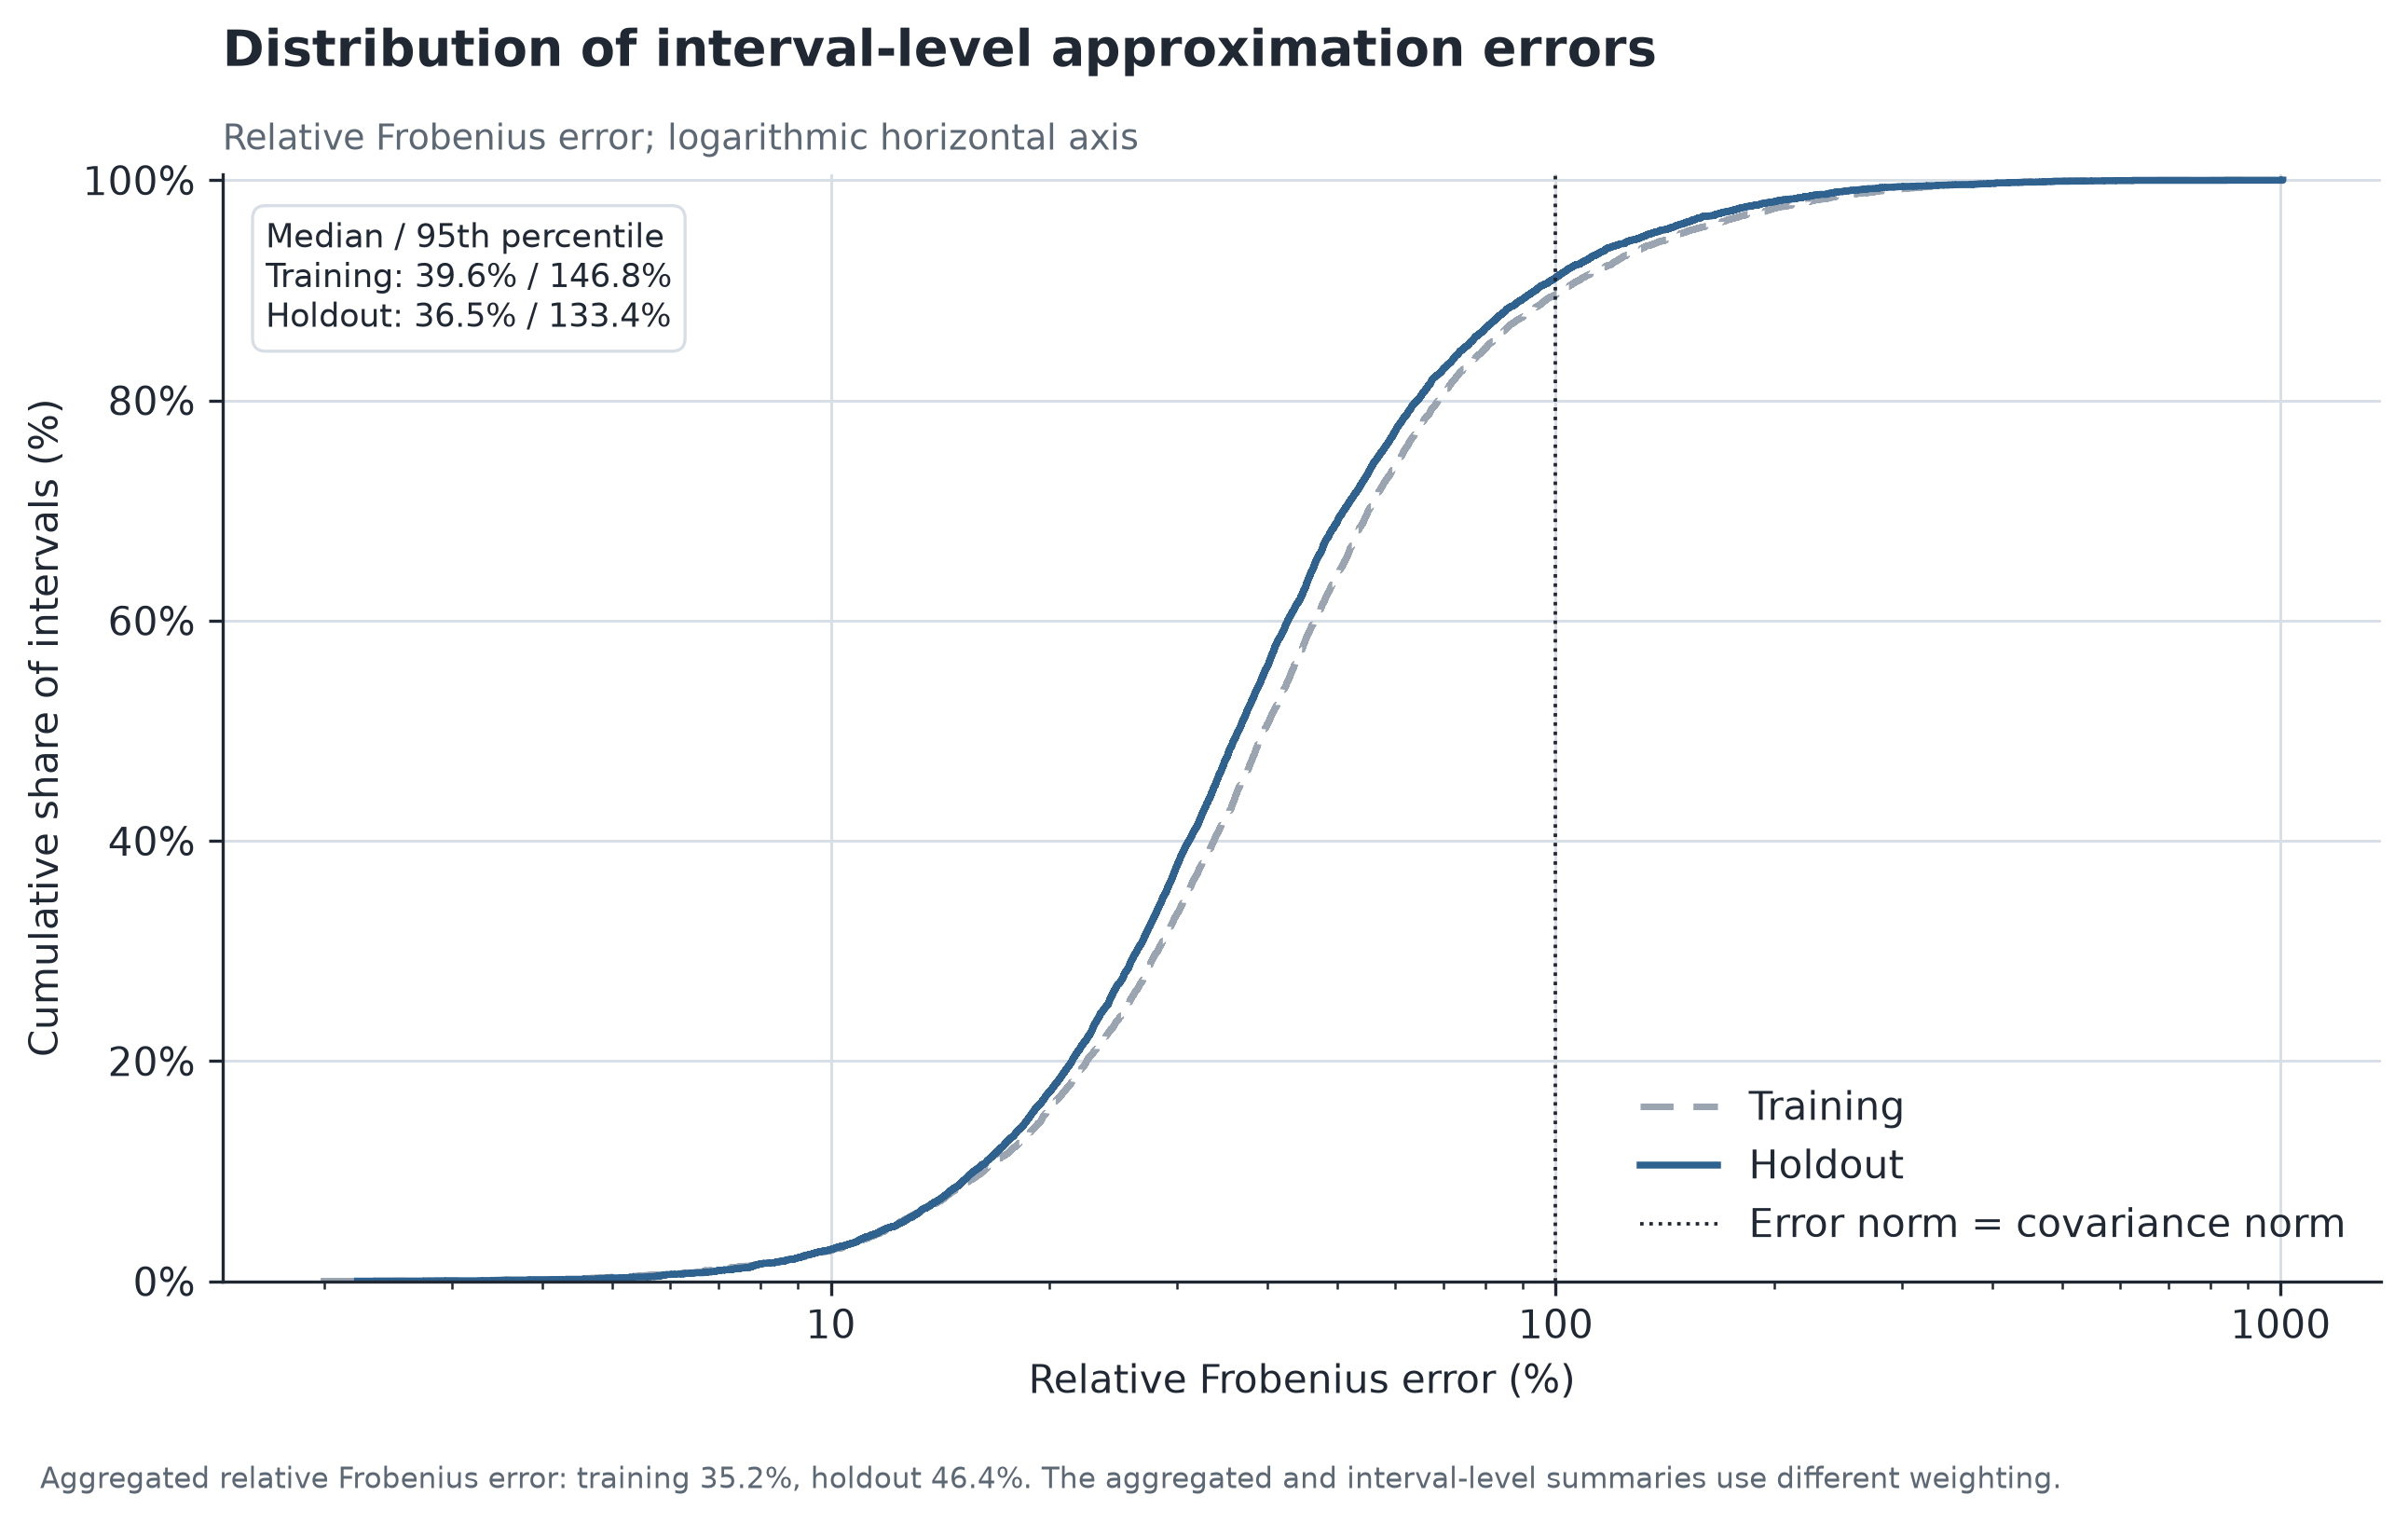

#### `05_covariance_rmse_reduction`

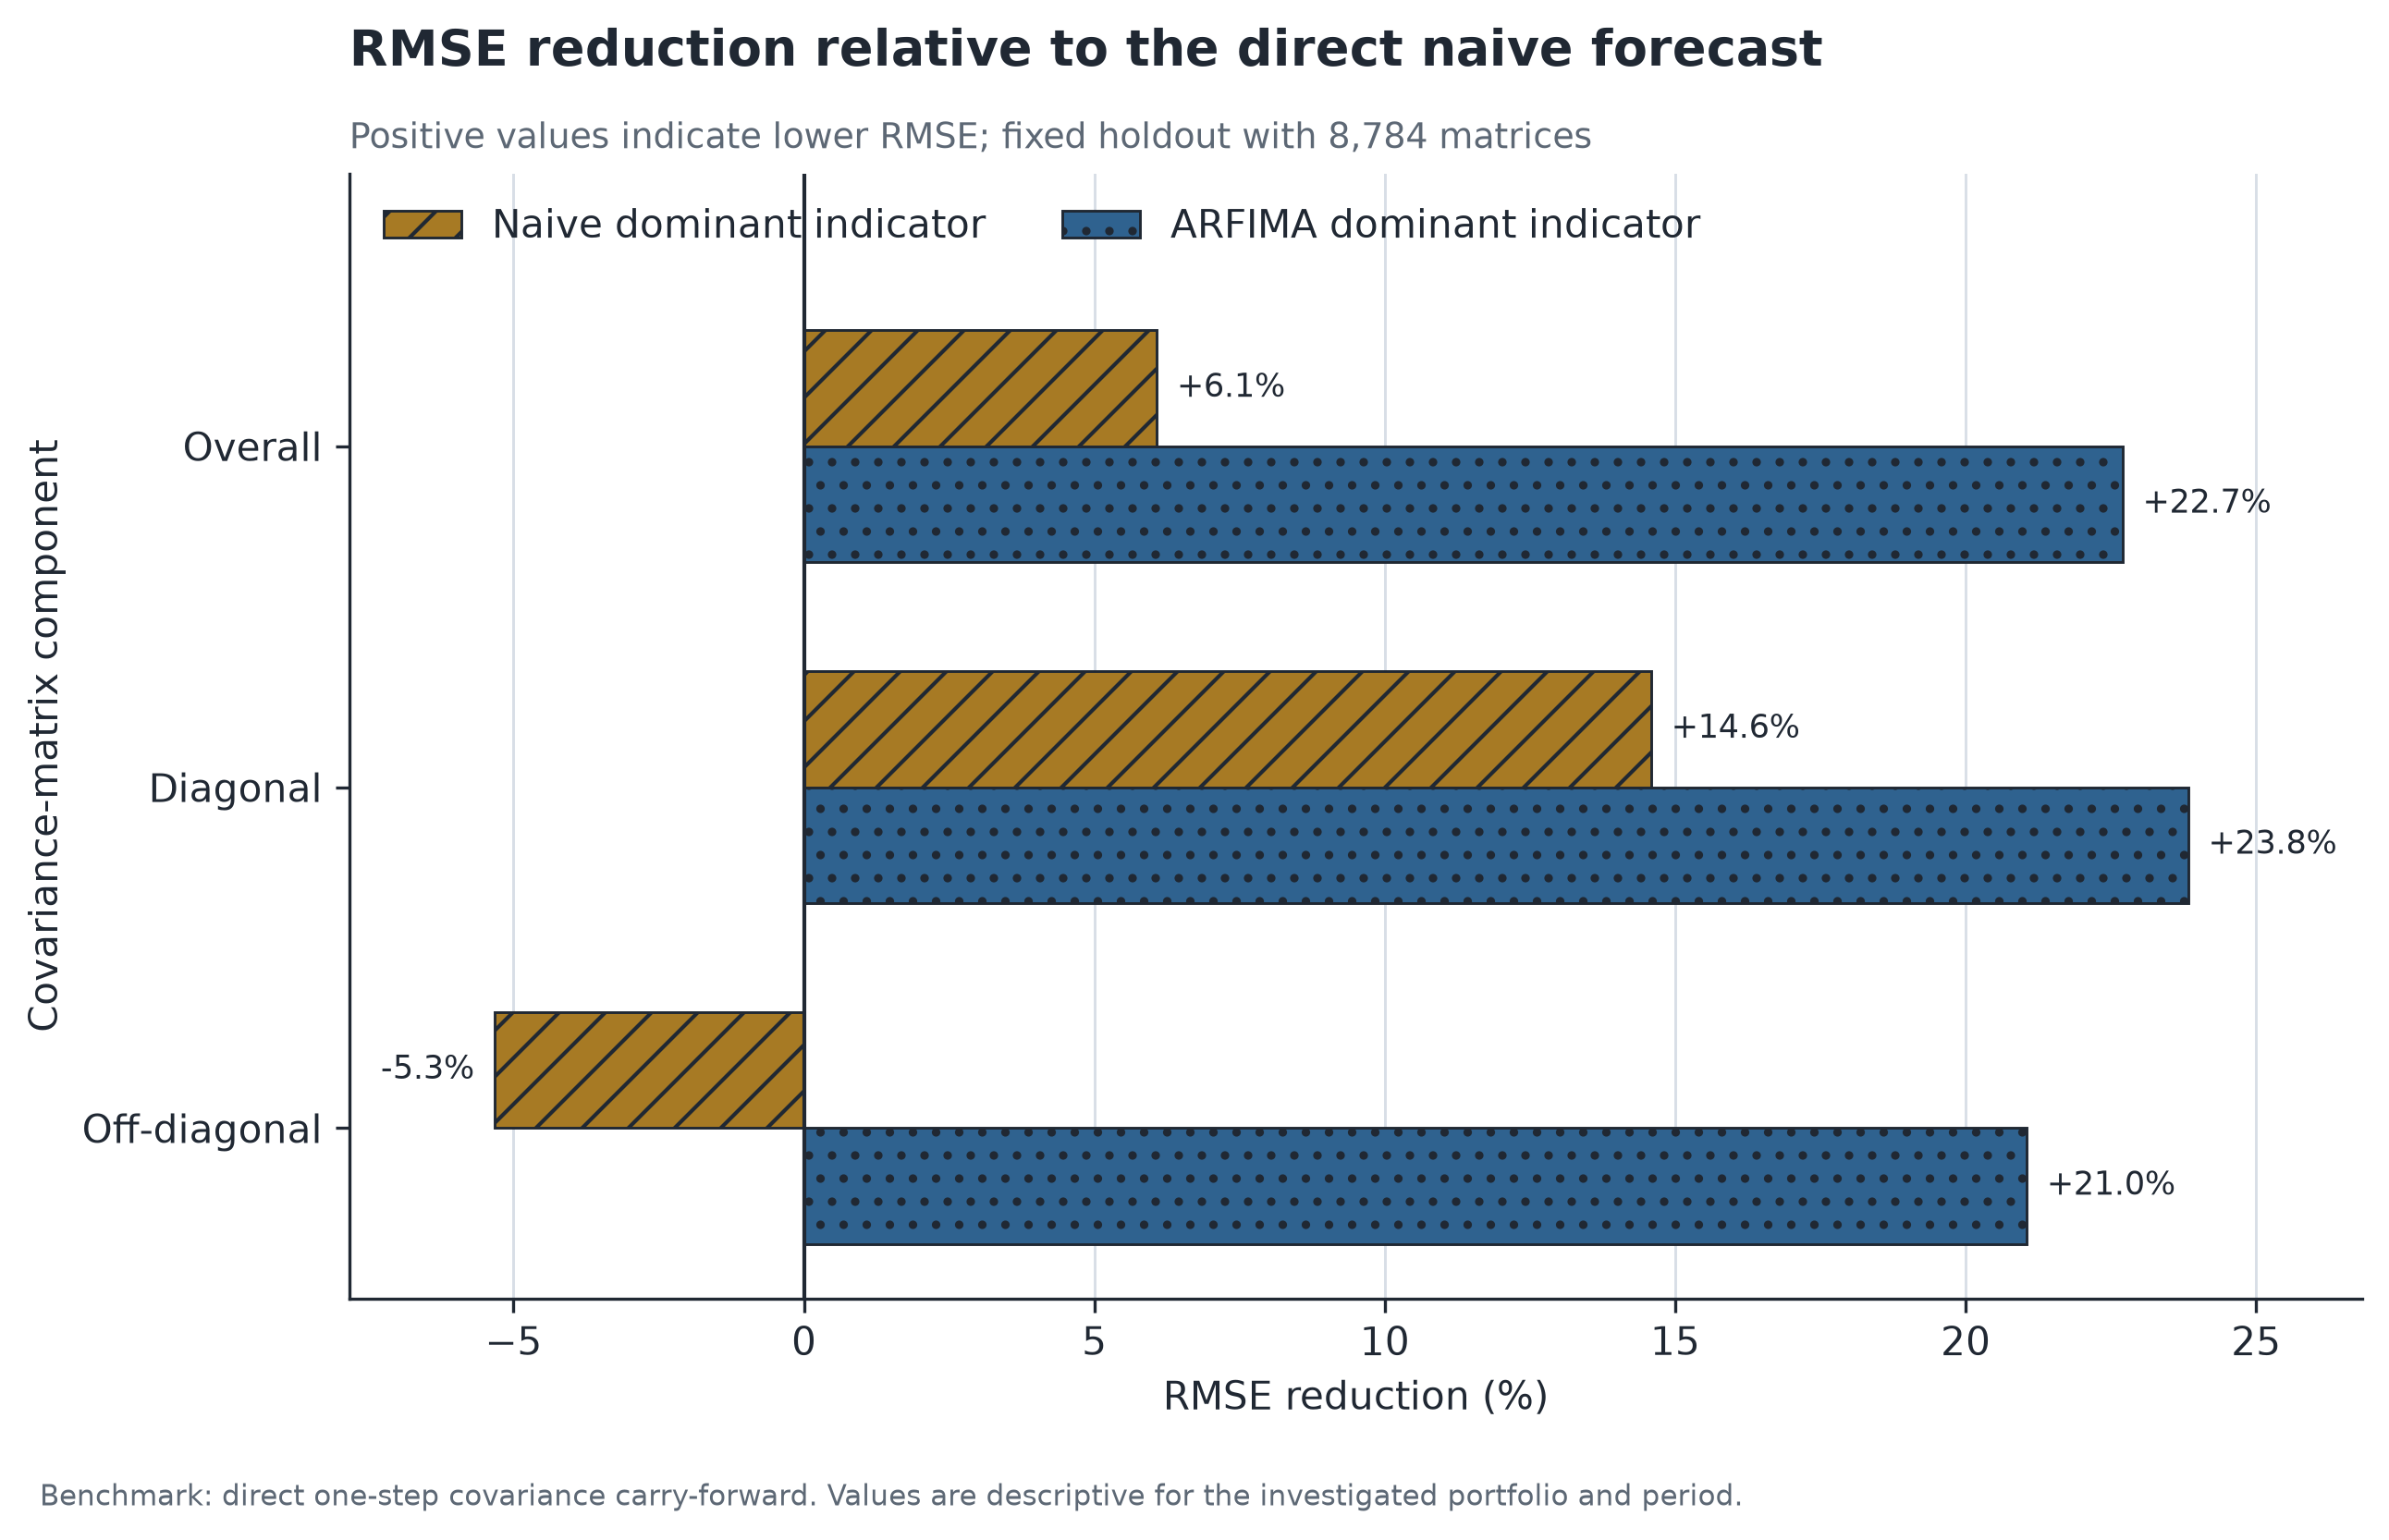

#### `06_cumulative_loss_difference`

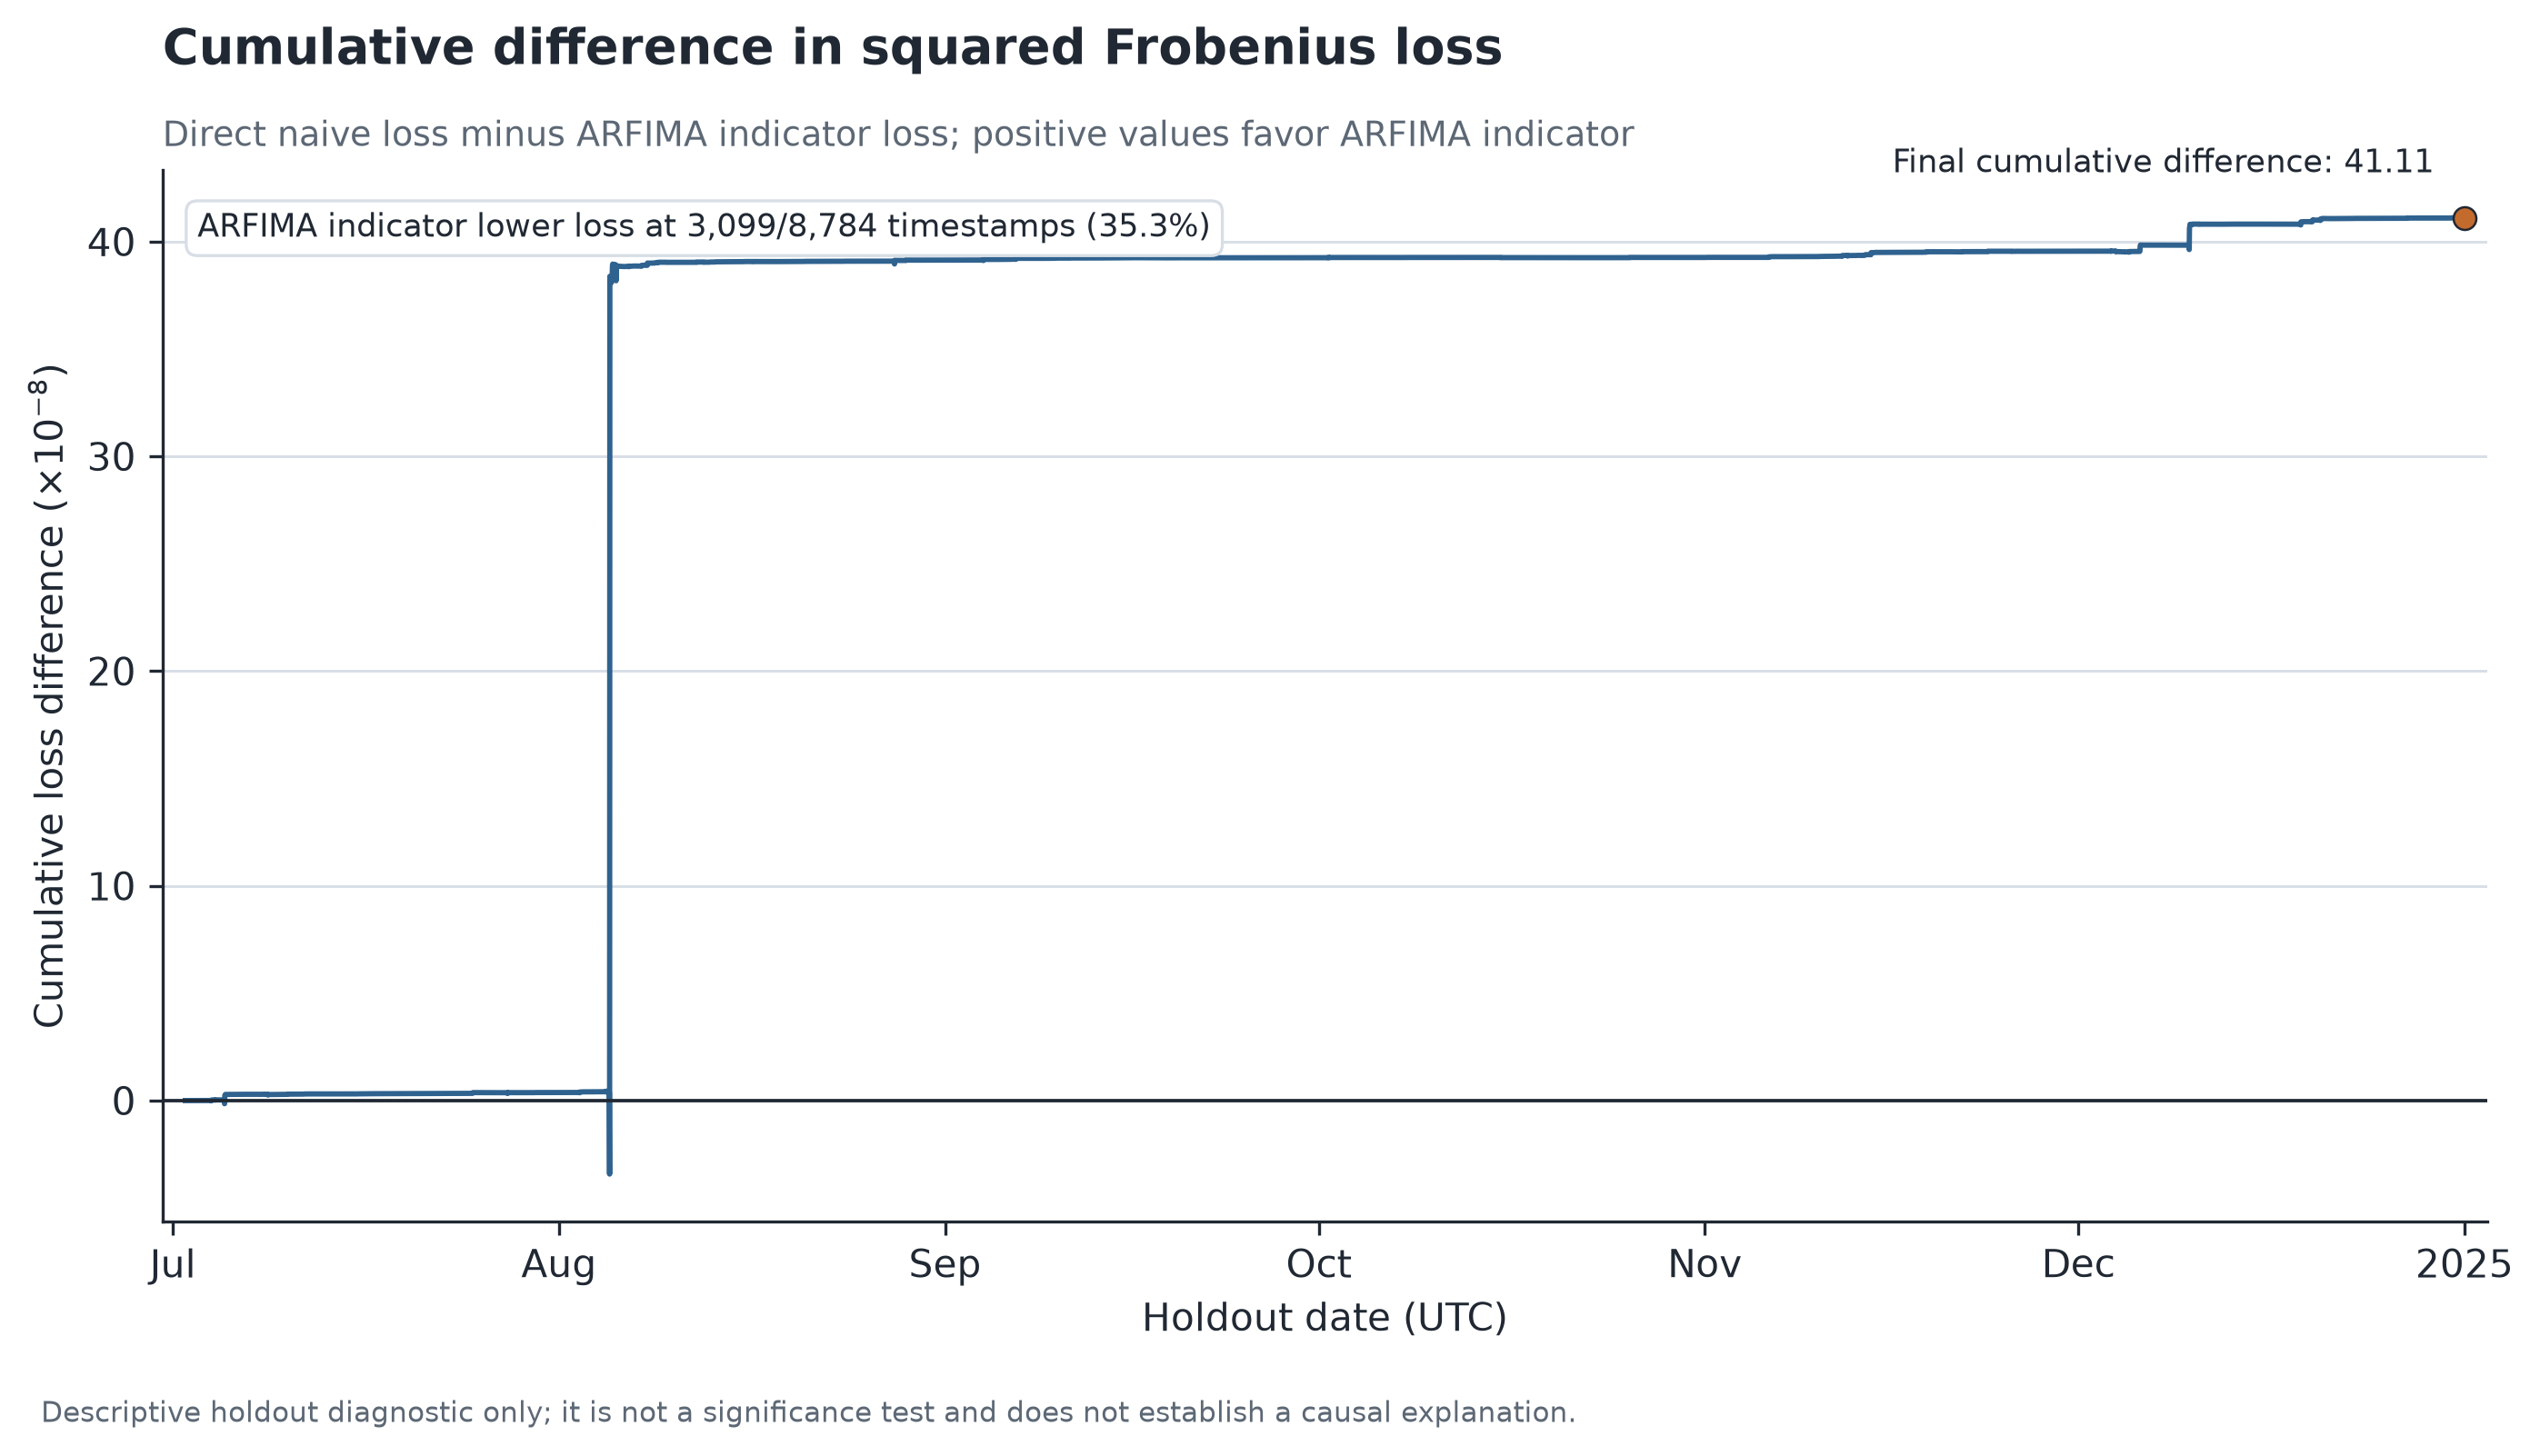

In [ ]:
configure_plot_style()
temporary_figure_directory = tempfile.TemporaryDirectory(
    prefix="pca-thesis-notebook-"
)
notebook_figure_directory = Path(temporary_figure_directory.name)

plot_reference_pca_variance_share(
    reference_eigenvalues,
    notebook_figure_directory,
)
plot_approximation_error_distributions(
    training_relative_errors,
    holdout_relative_errors,
    aggregated_training_error,
    aggregated_holdout_error,
    notebook_figure_directory,
)

rmse_plot_input = rmse_by_method.rename(
    index={label: key for key, label in METHOD_LABELS.items()}
)
plot_covariance_rmse_reduction(
    rmse_plot_input,
    len(holdout_timestamps),
    notebook_figure_directory,
)
plot_cumulative_loss_difference(
    direct_naive_losses,
    arfima_losses,
    "Direct naive",
    "ARFIMA indicator",
    "06_cumulative_loss_difference",
    notebook_figure_directory,
)

thesis_figure_stems = (
    "02_reference_pca_variance_share",
    "04_approximation_error_distributions",
    "05_covariance_rmse_reduction",
    "06_cumulative_loss_difference",
)
for stem in thesis_figure_stems:
    image_path = notebook_figure_directory / f"{stem}.png"
    if not image_path.is_file():
        raise FileNotFoundError(image_path)
    display(Markdown(f"#### `{stem}`"))
    display(Image(filename=image_path, width=850))

## Reproduction Checks

Two types of checks are used. Unit tests verify the behaviour of individual
mathematical and data-processing functions. End-to-end reconciliation
then verifies that the complete notebook reproduces the headline numbers
and figures used in the thesis.

### 13. Run the Unit Tests

The test suite covers fractional-differencing weights, Profile-Whittle
inputs and optimization, expanding-history forecasts, covariance
reconstruction, persistence benchmarks, error aggregation, loss
calculations, and positive-semidefiniteness diagnostics.

In [ ]:
test_result = subprocess.run(
    [sys.executable, "-m", "unittest", "discover", "-s", "tests"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    check=False,
)
test_output = "\n".join(
    part.strip() for part in (test_result.stdout, test_result.stderr) if part.strip()
)
print(test_output)
if test_result.returncode != 0:
    raise RuntimeError("The unit-test suite failed.")

......................
----------------------------------------------------------------------
Ran 22 tests in 0.066s

OK


### 14. Reconcile the Headline Results

The final assertions compare the newly computed values with the reference
result tables stored in the repository. These values are used only for
acceptance
checks after the calculations; they are not inputs to the analysis. Any
discrepancy stops execution and identifies the failed check.

In [ ]:
expected_rmse = pd.DataFrame(
    {
        "overall": [
            3.5946288689157667e-06,
            3.3764352654719857e-06,
            2.7787653132229465e-06,
        ],
        "diagonal": [
            4.814773340477625e-06,
            4.112713069087083e-06,
            3.6675973341095774e-06,
        ],
        "off-diagonal": [
            2.791238774769534e-06,
            2.9399435808471677e-06,
            2.203785356238827e-06,
        ],
    },
    index=[
        "Direct naive covariance",
        "Naive dominant indicator",
        "ARFIMA dominant indicator",
    ],
)
expected_rmse.index.name = "method"

checks = pd.Series(
    {
        "36 supplied archives and checksum sidecars": (
            len(archive_paths) == 36 and len(checksum_paths) == 36
        ),
        "527,040 prices per asset": len(closing_prices) == 527_040,
        "527,039 returns per asset": len(log_returns) == 527_039,
        "17,567 complete covariance matrices": len(covariance_timestamps) == 17_567,
        "8,783 / 8,784 chronological split": (
            len(training_timestamps) == 8_783 and len(holdout_timestamps) == 8_784
        ),
        "Leading reference share matches stored reference": np.isclose(
            variance_shares.iloc[0] * 100.0,
            79.73137381168341,
            rtol=1e-12,
            atol=1e-12,
        ),
        "Training approximation error matches stored reference": np.isclose(
            aggregated_training_error,
            0.35186784682877914,
            rtol=1e-12,
            atol=1e-12,
        ),
        "Holdout approximation error matches stored reference": np.isclose(
            aggregated_holdout_error,
            0.46382524188003976,
            rtol=1e-12,
            atol=1e-12,
        ),
        "ARFIMA d matches the reported six-decimal estimate": (
            round(float(fitted_arfima["d"]), 6) == 0.260204
        ),
        "RMSE table matches stored reference": np.allclose(
            rmse_by_method.to_numpy(),
            expected_rmse.to_numpy(),
            rtol=1e-12,
            atol=1e-15,
        ),
        "All reproduced forecasts are positive semidefinite": (
            int(psd_summary["non_psd_count"].sum()) == 0
        ),
        "Four thesis figures were reproduced": all(
            (notebook_figure_directory / f"{stem}.png").is_file()
            for stem in thesis_figure_stems
        ),
        "Unit tests passed": test_result.returncode == 0,
    },
    name="passed",
)
if not bool(checks.all()):
    failed_checks = checks.index[~checks].tolist()
    raise AssertionError(f"Reproduction checks failed: {failed_checks}")

verification_summary = checks.map({True: "PASS", False: "FAIL"}).to_frame()
display(verification_summary)

,passed
36 supplied archives and checksum sidecars,PASS
"527,040 prices per asset",PASS
"527,039 returns per asset",PASS
"17,567 complete covariance matrices",PASS
"8,783 / 8,784 chronological split",PASS
Leading reference share matches stored reference,PASS
Training approximation error matches stored reference,PASS
Holdout approximation error matches stored reference,PASS
ARFIMA d matches the reported six-decimal estimate,PASS
RMSE table matches stored reference,PASS


Every acceptance check must display **PASS**. Together with the successful
unit-test run, this confirms that the notebook reproduces the supplied
data counts, split, PCA result, approximation errors, ARFIMA estimate,
RMSE table, PSD result, and four thesis figures.

## What the Reproduction Shows

In [ ]:
direct_overall_rmse = rmse_by_method.loc[
    "Direct naive covariance", "overall"
]
naive_overall_rmse = rmse_by_method.loc[
    "Naive dominant indicator", "overall"
]
arfima_overall_rmse = rmse_by_method.loc[
    "ARFIMA dominant indicator", "overall"
]
naive_off_diagonal_rmse = rmse_by_method.loc[
    "Naive dominant indicator", "off-diagonal"
]
direct_off_diagonal_rmse = rmse_by_method.loc[
    "Direct naive covariance", "off-diagonal"
]
naive_reduction_percent = (
    1.0 - naive_overall_rmse / direct_overall_rmse
) * 100.0
arfima_reduction_percent = (
    1.0 - arfima_overall_rmse / direct_overall_rmse
) * 100.0
naive_off_diagonal_increase_percent = (
    naive_off_diagonal_rmse / direct_off_diagonal_rmse - 1.0
) * 100.0
arfima_lower_loss_count = int(
    (direct_naive_losses - arfima_losses).gt(0.0).sum()
)
arfima_lower_loss_share = (
    arfima_lower_loss_count / len(holdout_timestamps) * 100.0
)

display(Markdown(
    f'''\
    1. **The leading direction is important, but the reduction is not
       lossless.** PC1 accounts for
       **{variance_shares.iloc[0] * 100:.1f}%** of the
       training-reference eigenvalue sum. Nevertheless, the aggregated
       one-indicator approximation error is
       **{aggregated_training_error * 100:.1f}% in training** and
       **{aggregated_holdout_error * 100:.1f}% in the holdout**.

    2. **The ARFIMA indicator method has the lowest aggregate holdout
       RMSE in this case study.** Its overall RMSE is
       **{arfima_reduction_percent:.1f}% lower** than direct covariance
       persistence. The naive indicator also lowers overall RMSE by
       **{naive_reduction_percent:.1f}%**, but its off-diagonal RMSE is
       **{naive_off_diagonal_increase_percent:.1f}% higher**.

    3. **The aggregate advantage is concentrated in a minority of
       timestamps.** ARFIMA has lower squared Frobenius loss than the
       direct naive benchmark at
       **{arfima_lower_loss_count:,} of {len(holdout_timestamps):,}
       timestamps ({arfima_lower_loss_share:.1f}%)**. A relatively small
       number of large loss differences therefore has substantial
       influence on the aggregate ranking.

    4. **All reconstructed forecasts remain valid covariance
       matrices under the PSD diagnostic.** No non-PSD forecast is
       found for any of the three methods.

    These statements reproduce the empirical findings for the fixed
    2024 design. They do not establish statistical significance,
    causal mechanisms, or general superiority in other samples.
    '''
))

    1. **The leading direction is important, but the reduction is not
       lossless.** PC1 accounts for
       **79.7%** of the
       training-reference eigenvalue sum. Nevertheless, the aggregated
       one-indicator approximation error is
       **35.2% in training** and
       **46.4% in the holdout**.

    2. **The ARFIMA indicator method has the lowest aggregate holdout
       RMSE in this case study.** Its overall RMSE is
       **22.7% lower** than direct covariance
       persistence. The naive indicator also lowers overall RMSE by
       **6.1%**, but its off-diagonal RMSE is
       **5.3% higher**.

    3. **The aggregate advantage is concentrated in a minority of
       timestamps.** ARFIMA has lower squared Frobenius loss than the
       direct naive benchmark at
       **3,099 of 8,784
       timestamps (35.3%)**. A relatively small
       number of large loss differences therefore has substantial
       influence on the aggregate ranking.

    4. **All reconstructed forecasts remain valid covariance
       matrices under the PSD diagnostic.** No non-PSD forecast is
       found for any of the three methods.

    These statements reproduce the empirical findings for the fixed
    2024 design. They do not establish statistical significance,
    causal mechanisms, or general superiority in other samples.
    

## How to Rerun the Notebook

From the repository root, create the locked notebook environment and open
the executed artifact:

```bash
uv sync --frozen --group notebook
uv run --group notebook jupyter lab notebooks/reproduce_thesis_results.ipynb
```

For a non-interactive top-to-bottom verification run:

```bash
uv run --group notebook jupyter nbconvert --execute --to notebook --inplace --ExecutePreprocessor.timeout=1800 notebooks/reproduce_thesis_results.ipynb
```

The notebook expects the supplied data under `data/raw/binance/`. It does
not download files automatically, alter the model specification, or run
analyses outside the scope of the thesis.